In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 20)

In [22]:
# 1. Создаём свой класс Dataset для PyTorch
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Токенизируем текст
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            # padding=False,
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [23]:
import pandas as pd

df = pd.read_csv('../dataset/texts_from_avito.csv', sep=';')
df = df[df['тема'].notna()]
df = df[df['текст'].notna()]
df = df[['тема', 'текст']]

df = df[df['тема'] != "вышка тура"]
df = df[df['тема'] != "плиткорез электрический"]
df = df[df['тема'] != "реноватор аккумуляторный"]
df = df[df['тема'] != "присоска"]
df = df[df['тема'] != "нивелир оптический"]
df = df[df['тема'] != "детектор проводки"]
df = df[df['тема'] != "дрель магнитная"]

# df = df[df['тема'] != "не вопрос клиента"]
df

,тема,текст
0,шуруповерт,"добрый вечер! подскажите, у вас можно взять в ..."
1,пылесос,Здравствуйте) сколько стоит аренда строительно...
2,плиткорез ручной,Доброе утро. Подскажите пожалуйста в какую цен...
3,фен,Доброе утро Есть строительный фен на аккумулят...
4,не вопрос клиента,Добрый день
...,...,...
911,дрель для алмазного бурения,"Добрый утро, есть дрель для сухого алмазного ..."
912,штроборез,"Здравствуйте, хотел бы взять у вас в прокат ш..."
913,не вопрос клиента,Здравствуйте
914,домкрат бутылочный,Здравствуйте! Какие домкраты есть в аренду с ...


In [24]:
def clear_text(text: str) -> str:
    # функция очистки текстов от паразитных слов, не относящихся к теме запроса
    
    trash_values = [
        'добрый вечер', 
        'добрый день', 
        'доброе утро',
        'добрый утро',
        'здравствуйте',
        'подскажите',
        'пожалуйста',
        'хотелось',
        'интересует',
        'нужен',
        'нужно',
        'хочу',
        'надо',
        'можно',
        'аренда',
        'аренду',
        'хочу',
        'хотел бы',
        'в наличии',
        'сколько стоит',
        ',',
        "'",
    ]
    text = text.lower()
    for value in trash_values:
        text = text.replace(value, '')
    return text

In [25]:
df['текст'] = df['текст'].map(clear_text)
df

,тема,текст
0,шуруповерт,! у вас взять в шурповерт?
1,пылесос,) строительного пылесоса на сутки?
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...
3,фен,есть строительный фен на аккумуляторной батареи?
4,не вопрос клиента,
...,...,...
911,дрель для алмазного бурения,есть дрель для сухого алмазного бурения?
912,штроборез,взять у вас в прокат штроборез он у вас сво...
913,не вопрос клиента,
914,домкрат бутылочный,! какие домкраты есть в с вечера четверга по...


In [26]:
df['номер темы'] = df['тема'].astype('category').cat.codes
df

,тема,текст,номер темы
0,шуруповерт,! у вас взять в шурповерт?,82
1,пылесос,) строительного пылесоса на сутки?,59
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...,51
3,фен,есть строительный фен на аккумуляторной батареи?,76
4,не вопрос клиента,,35
...,...,...,...
911,дрель для алмазного бурения,есть дрель для сухого алмазного бурения?,17
912,штроборез,взять у вас в прокат штроборез он у вас сво...,81
913,не вопрос клиента,,35
914,домкрат бутылочный,! какие домкраты есть в с вечера четверга по...,15


In [27]:
df_small = df[df['тема']=='бензорез']
df_small

,тема,текст,номер темы
36,бензорез,. бензорез у вас есть?,4
260,бензорез,у вас есть в бетонорез?,4
686,бензорез,бензорез под 400 диск хускварна. есть такой?,4
818,бензорез,. с большим диском по бетону на сутки по како...,4
891,бензорез,есть ли бензорез с 400 диском в на одни сутки?,4


In [28]:
summary = df['тема'].value_counts()
print(summary)

тема
не вопрос клиента                126
перфоратор                        79
пылесос                           65
торцовочная пила                  45
нет такого инструмента            36
                                ... 
сабельная пила аккумуляторная      1
бензопила                          1
тачка                              1
прогрев бетона                     1
домкрат бутылочный                 1
Name: count, Length: 83, dtype: int64


In [30]:
labels_df = df[['номер темы', 'тема']]
labels_df = labels_df.drop_duplicates(subset=['номер темы'])
labels_df = labels_df.sort_values(by='номер темы')
labels_df

,номер темы,тема
41,0,УШМ
43,1,УШМ аккумуляторная
368,2,бензобур
337,3,бензопила
36,4,бензорез
...,...,...
159,78,фрезер
167,79,шлифовальная машина
644,80,шнек для бензобура
109,81,штроборез


In [31]:
labels_df.to_csv('../dataset/labels_base.csv')

In [32]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(df, test_size=0.1, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 817, Val: 45, Test: 46


In [33]:
train_texts = train['текст'].tolist()
train_labels = train['номер темы'].tolist()
val_texts = val['текст'].tolist()
val_labels = val['номер темы'].tolist()
test_texts = test['текст'].tolist()
test_labels = test['номер темы'].tolist()

In [34]:
# 4. Настраиваем параметры обучения
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,          
    per_device_train_batch_size=4, # маленький батч для CPU
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    dataloader_pin_memory=False,
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [35]:
# 5. Функция для подсчёта метрик
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [36]:
training_results = {}

## Модель DeepPavlov/rubert-base-cased

In [37]:
# 2. Загружаем модель и токенизатор
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

In [38]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer)

In [39]:
# 6. Запускаем обучение
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.230534,2.987386,0.355556,0.292593,0.355556,0.315556
2,1.454272,2.200244,0.577778,0.551852,0.577778,0.555556
3,1.005508,1.487700,0.777778,0.781481,0.777778,0.770101
4,0.388846,1.410656,0.777778,0.803704,0.777778,0.777508
5,0.315439,1.239289,0.755556,0.737037,0.755556,0.740471
6,0.047413,1.228381,0.800000,0.807407,0.800000,0.801212
7,0.391460,1.121735,0.800000,0.837037,0.800000,0.809254
8,0.339680,1.083049,0.777778,0.785185,0.777778,0.778990
9,0.177705,1.110004,0.800000,0.796296,0.800000,0.793805
10,0.436612,1.098545,0.800000,0.807407,0.800000,0.801212


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=4100, training_loss=0.5106499326633426, metrics={'train_runtime': 1018.2002, 'train_samples_per_second': 16.048, 'train_steps_per_second': 4.027, 'total_flos': 1075590333281280.0, 'train_loss': 0.5106499326633426, 'epoch': 20.0})

In [40]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_') + '_base'
model.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


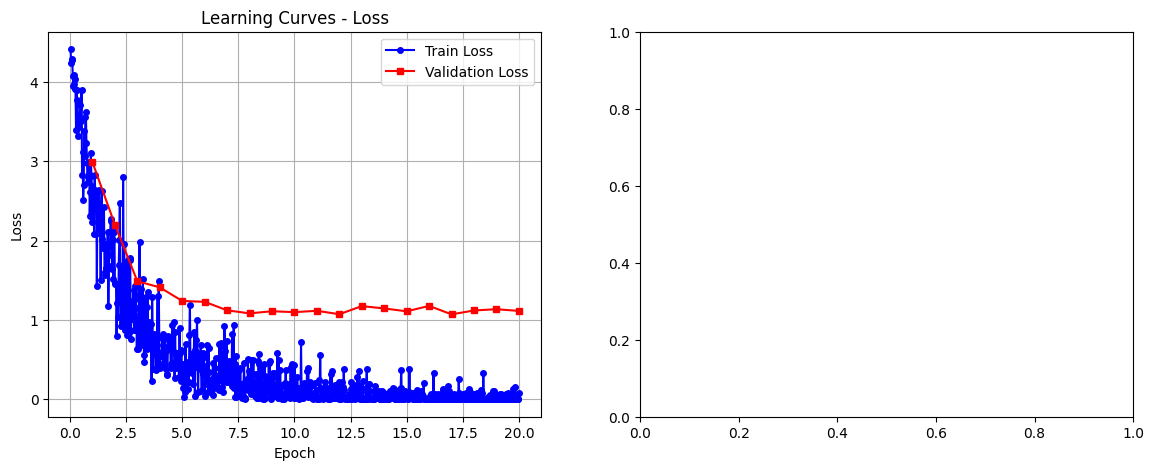

In [41]:
# Извлекаем историю обучения
log_history = trainer.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [42]:
print("🔮 Делаем предсказания на тестовой выборке...")
model = model.to('mps')
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8043
  precision: 0.7717
  recall: 0.8043
  f1: 0.7731


In [43]:
training_results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8043478260869565,
  'precision': 0.7717391304347826,
  'recall': 0.8043478260869565,
  'f1': 0.7730895915678524}}

## Модель rubert-tiny2

In [44]:
# 2. Загружаем модель и токенизатор
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "cointegrated/rubert-tiny2"
tokenizer2 = AutoTokenizer.from_pretrained(model_name)
model2 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

In [45]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer2)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer2)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer2)

In [46]:
trainer2 = Trainer(
    model=model2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer2.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.382322,3.845916,0.244444,0.109942,0.244444,0.132660
2,2.429102,3.185731,0.333333,0.208704,0.333333,0.240067
3,2.179664,2.734558,0.488889,0.395556,0.488889,0.421164
4,1.719748,2.432123,0.600000,0.564074,0.600000,0.564021
5,1.842463,2.270312,0.622222,0.580741,0.622222,0.590741
6,1.059895,2.085635,0.622222,0.577778,0.622222,0.586667
7,1.270519,1.971709,0.711111,0.740741,0.711111,0.713805
8,1.293609,1.851309,0.733333,0.733333,0.733333,0.722694
9,0.835648,1.788806,0.711111,0.722222,0.711111,0.703434
10,1.339607,1.727085,0.733333,0.774074,0.733333,0.738249


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=4100, training_loss=1.254969807623363, metrics={'train_runtime': 145.4955, 'train_samples_per_second': 112.306, 'train_steps_per_second': 28.18, 'total_flos': 30441793336320.0, 'train_loss': 1.254969807623363, 'epoch': 20.0})

In [47]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_') + '_base'
model2.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer2.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


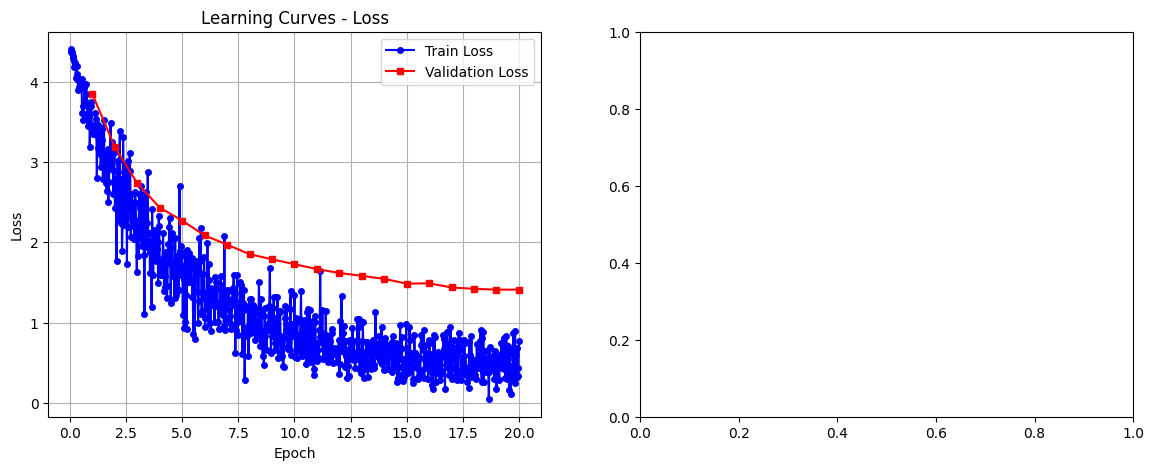

In [48]:
# Извлекаем историю обучения
log_history = trainer2.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

## Анализ метрик

In [49]:
print("🔮 Делаем предсказания на тестовой выборке...")
model2 = model2.to('mps')
predictions = trainer2.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8043
  precision: 0.7612
  recall: 0.8043
  f1: 0.7619


In [50]:
training_results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8043478260869565,
  'precision': 0.7717391304347826,
  'recall': 0.8043478260869565,
  'f1': 0.7730895915678524},
 'cointegrated/rubert-tiny2': {'accuracy': 0.8043478260869565,
  'precision': 0.7612146307798481,
  'recall': 0.8043478260869565,
  'f1': 0.7618712702472294}}

## ai-forever/ruElectra-small

In [51]:
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "ai-forever/ruElectra-small"
tokenizer3 = AutoTokenizer.from_pretrained(model_name)
model3 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: ai-forever/ruElectra-small
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
generator.encoder.layer.{0...11}.output.dense.bias                 | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.value.weight       | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.query.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.value.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.LayerNorm.bias             | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.LayerNorm.weight           | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.dense.bias       | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.dense.weight     | UNEXPECTED | 
discriminator_predictions.LayerNorm.bias                           | UNEXPECTED | 
generator

In [52]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer3)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer3)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer3)

In [53]:
trainer3 = Trainer(
    model=model3,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer3.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.147895,4.247262,0.177778,0.063049,0.177778,0.077098
2,3.724152,4.070282,0.177778,0.041734,0.177778,0.063672
3,3.842969,3.964171,0.044444,0.006349,0.044444,0.011111
4,3.445387,3.747994,0.066667,0.012382,0.066667,0.020882
5,3.454737,3.565040,0.133333,0.061032,0.133333,0.081874
6,2.703030,3.460358,0.244444,0.155983,0.244444,0.185798
7,3.228500,3.367516,0.266667,0.187542,0.266667,0.211578
8,3.483592,3.287791,0.266667,0.161538,0.266667,0.194687
9,2.661680,3.217856,0.266667,0.180952,0.266667,0.205556
10,3.544762,3.146862,0.288889,0.198124,0.288889,0.225599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=4100, training_loss=2.792001081210811, metrics={'train_runtime': 285.6229, 'train_samples_per_second': 57.208, 'train_steps_per_second': 14.355, 'total_flos': 120440467829760.0, 'train_loss': 2.792001081210811, 'epoch': 20.0})

In [54]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_') + '_base'
model3.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer3.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


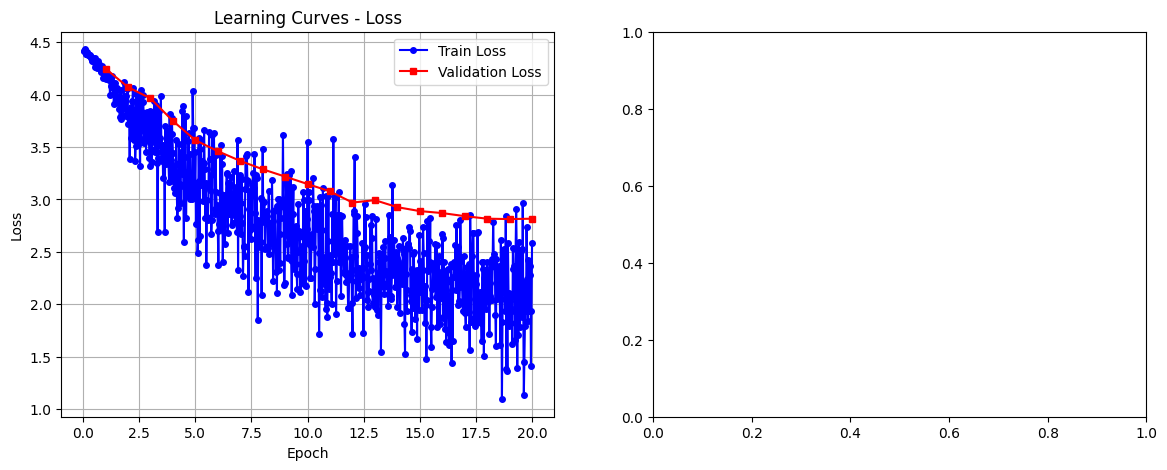

In [55]:
# Извлекаем историю обучения
log_history = trainer3.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [56]:
print("🔮 Делаем предсказания на тестовой выборке...")
model3 = model3.to('mps')
predictions = trainer3.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.3261
  precision: 0.2484
  recall: 0.3261
  f1: 0.2502


In [57]:
training_results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8043478260869565,
  'precision': 0.7717391304347826,
  'recall': 0.8043478260869565,
  'f1': 0.7730895915678524},
 'cointegrated/rubert-tiny2': {'accuracy': 0.8043478260869565,
  'precision': 0.7612146307798481,
  'recall': 0.8043478260869565,
  'f1': 0.7618712702472294},
 'ai-forever/ruElectra-small': {'accuracy': 0.32608695652173914,
  'precision': 0.2484472049689441,
  'recall': 0.32608695652173914,
  'f1': 0.25023791362464126}}

In [58]:
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "ai-forever/ruElectra-medium"
tokenizer4 = AutoTokenizer.from_pretrained(model_name)
model4 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: ai-forever/ruElectra-medium
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
generator.encoder.layer.{0...11}.output.dense.bias                 | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.value.weight       | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.query.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.value.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.LayerNorm.bias             | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.LayerNorm.weight           | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.dense.bias       | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.dense.weight     | UNEXPECTED | 
discriminator_predictions.LayerNorm.bias                           | UNEXPECTED | 
generato

In [59]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer4)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer4)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer4)

In [60]:
trainer4 = Trainer(
    model=model4,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer4.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.133118,3.684154,0.222222,0.085556,0.222222,0.119841
2,2.118108,2.977876,0.311111,0.225926,0.311111,0.246138
3,2.099745,2.553842,0.355556,0.279630,0.355556,0.303069
4,1.497484,2.318331,0.466667,0.381481,0.466667,0.393699
5,1.415081,2.059887,0.511111,0.468519,0.511111,0.479259
6,0.764328,1.933120,0.622222,0.637037,0.622222,0.604916
7,0.958637,1.825851,0.555556,0.624074,0.555556,0.556768
8,1.091644,1.842410,0.577778,0.551852,0.577778,0.556768
9,0.671423,1.887850,0.711111,0.744444,0.711111,0.723329
10,0.826216,1.728328,0.622222,0.601852,0.622222,0.602694


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=4100, training_loss=1.0277267106636088, metrics={'train_runtime': 641.0445, 'train_samples_per_second': 25.49, 'train_steps_per_second': 6.396, 'total_flos': 605457329894400.0, 'train_loss': 1.0277267106636088, 'epoch': 20.0})

In [61]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_') + '_base'
model4.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer4.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


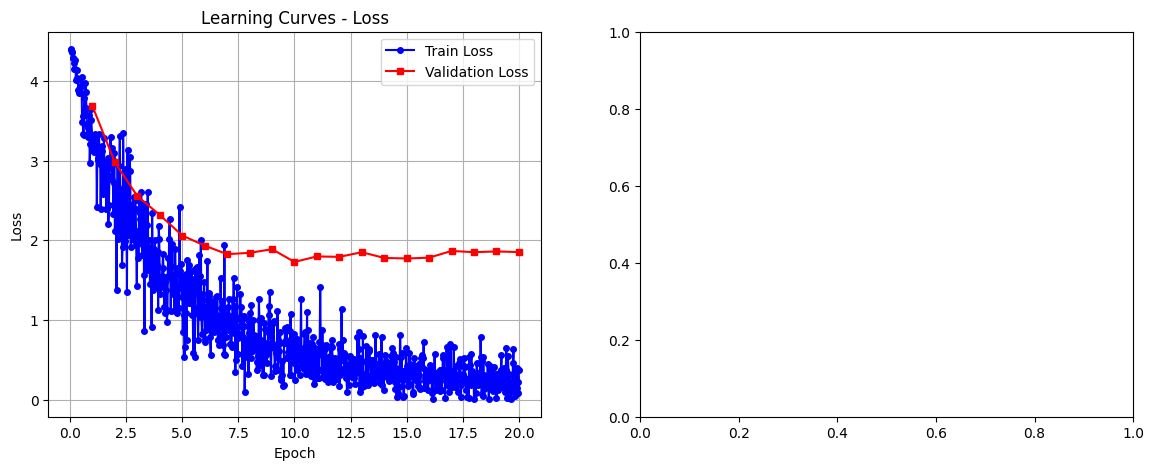

In [62]:
# Извлекаем историю обучения
log_history = trainer4.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [63]:
print("🔮 Делаем предсказания на тестовой выборке...")
model4 = model4.to('mps')
predictions = trainer4.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.7826
  precision: 0.7645
  recall: 0.7826
  f1: 0.7597


In [64]:
training_results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8043478260869565,
  'precision': 0.7717391304347826,
  'recall': 0.8043478260869565,
  'f1': 0.7730895915678524},
 'cointegrated/rubert-tiny2': {'accuracy': 0.8043478260869565,
  'precision': 0.7612146307798481,
  'recall': 0.8043478260869565,
  'f1': 0.7618712702472294},
 'ai-forever/ruElectra-small': {'accuracy': 0.32608695652173914,
  'precision': 0.2484472049689441,
  'recall': 0.32608695652173914,
  'f1': 0.25023791362464126},
 'ai-forever/ruElectra-medium': {'accuracy': 0.782608695652174,
  'precision': 0.7644927536231885,
  'recall': 0.782608695652174,
  'f1': 0.7596837944664031}}

In [65]:
results = {'DeepPavlov/rubert-base-cased': {'accuracy': 0.8043478260869565,
  'precision': 0.7717391304347826,
  'recall': 0.8043478260869565,
  'f1': 0.7730895915678524},
 'cointegrated/rubert-tiny2': {'accuracy': 0.8043478260869565,
  'precision': 0.7612146307798481,
  'recall': 0.8043478260869565,
  'f1': 0.7618712702472294},
 'ai-forever/ruElectra-small': {'accuracy': 0.32608695652173914,
  'precision': 0.2484472049689441,
  'recall': 0.32608695652173914,
  'f1': 0.25023791362464126},
 'ai-forever/ruElectra-medium': {'accuracy': 0.782608695652174,
  'precision': 0.7644927536231885,
  'recall': 0.782608695652174,
  'f1': 0.7596837944664031}}
results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8043478260869565,
  'precision': 0.7717391304347826,
  'recall': 0.8043478260869565,
  'f1': 0.7730895915678524},
 'cointegrated/rubert-tiny2': {'accuracy': 0.8043478260869565,
  'precision': 0.7612146307798481,
  'recall': 0.8043478260869565,
  'f1': 0.7618712702472294},
 'ai-forever/ruElectra-small': {'accuracy': 0.32608695652173914,
  'precision': 0.2484472049689441,
  'recall': 0.32608695652173914,
  'f1': 0.25023791362464126},
 'ai-forever/ruElectra-medium': {'accuracy': 0.782608695652174,
  'precision': 0.7644927536231885,
  'recall': 0.782608695652174,
  'f1': 0.7596837944664031}}